In [36]:
import pandas as pd

file_path = "./data/catalog-job_2026-05-31.csv.gz"

df = pd.read_csv(file_path)

print(df.head())
print(f"num of rows: {len(df):,}")

         # object_id         ra       dec  redshift  apparent_mag_i
0  36407037608853665  29.127434 -7.072824      1.00       22.656433
1  36407037608853670  29.124090 -7.072314      1.06       22.664356
2  36407037608853703  29.123477 -7.070190      0.55       21.820854
3  36407037608853707  29.126371 -7.069611      0.77       23.336664
4  36407037608853708  29.124621 -7.069684      0.90       23.177895
num of rows: 83,850,533


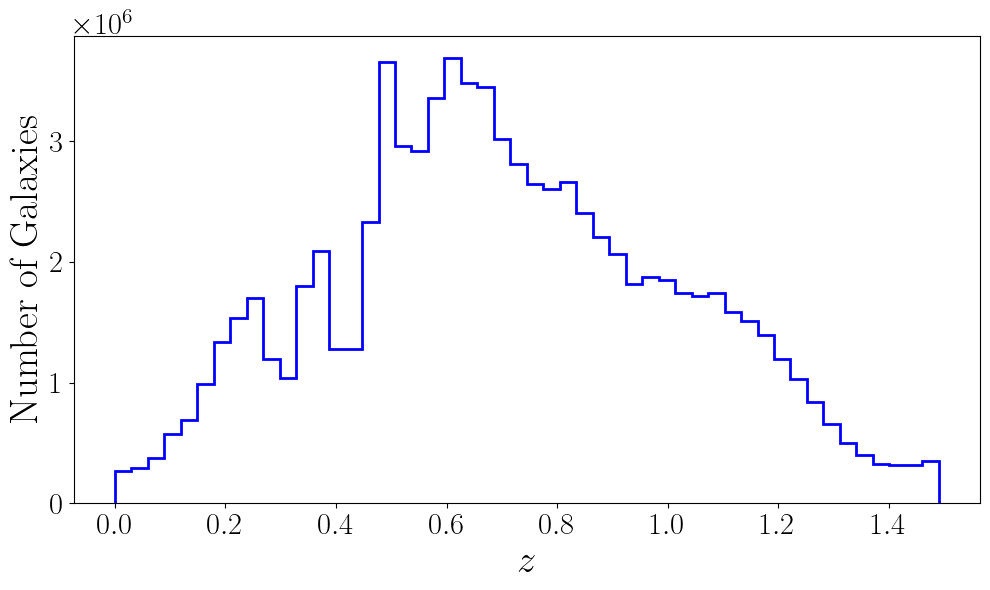

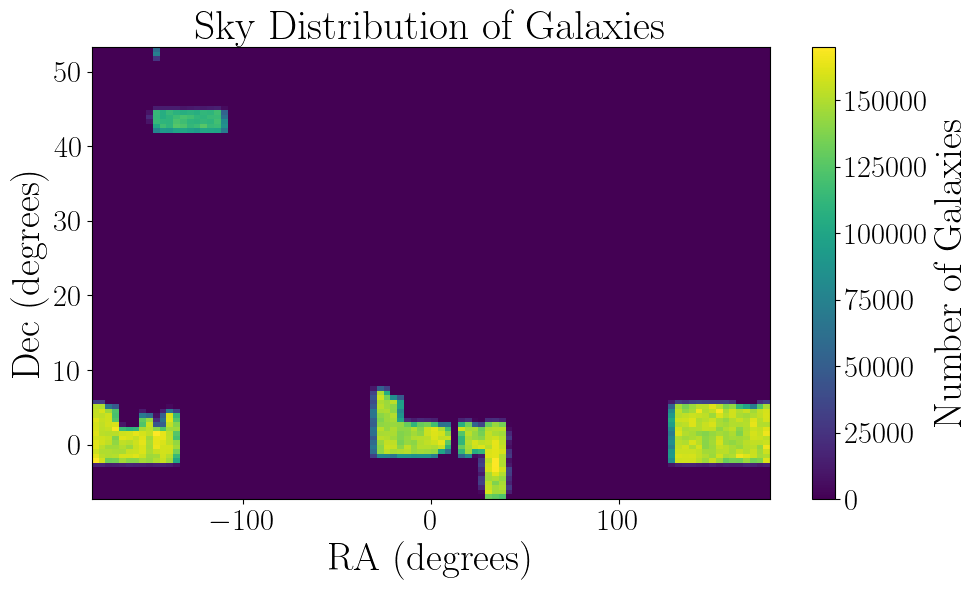

In [ ]:
import matplotlib.pyplot as plt

z_array = df["redshift"].values
ra_array = df["ra"].values
ra_array = (ra_array + 180) % 360 - 180
dec_array = df["dec"].values

plt.style.use("~/research/my_plot_style.style")
plt.figure()
plt.hist(z_array, bins=50, histtype="step", color="blue", lw=2)
plt.xlabel(r"$z$")
plt.ylabel("Number of Galaxies")
plt.grid()
plt.show()

plt.figure()
plt.hist2d(ra_array, dec_array, bins=100, cmap="viridis")
plt.colorbar(label="Number of Galaxies")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.title("Sky Distribution of Galaxies")
plt.grid()
plt.show()

RA range: -180.00 to 180.00 degrees
Dec range: -7.28 to 53.26 degrees


/Users/hayato/research/env/lib/python3.10/site-packages/healpy/visufunc.py:332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/visufunc.py:1506: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/visufunc.py:1568: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/visufunc.py:1590: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/Users/hayato/research/env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_lay

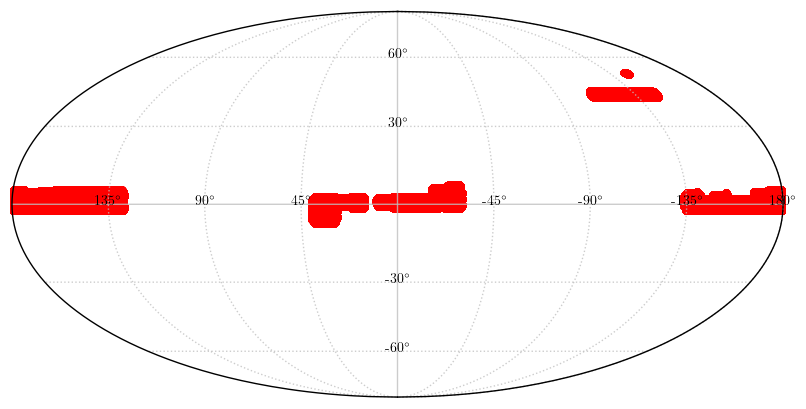

Pixel area: 0.0525 deg^2
Occupied pixels: 24493
Total covered area: 1284.80 deg^2
Number density in the covered area: 65263.43 galaxies/deg^2
Number density in the covered area: 18.13 galaxies/arcsec^2


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

ra = df["ra"].values
ra = (ra + 180) % 360 - 180
dec = df["dec"].values

print(f"RA range: {ra.min():.2f} to {ra.max():.2f} degrees")
print(f"Dec range: {dec.min():.2f} to {dec.max():.2f} degrees")

nside = 256
npix = hp.nside2npix(nside)
hpx_map_white = np.zeros(npix)

plt.style.use("~/research/my_plot_style.style")
plt.figure()
hp.mollview(hpx_map_white, 
            title="", 
            cbar=False, 
            cmap='Greys', 
            min=0, max=1,  # スケールを固定
            notext=True, 
            hold=True)
hp.graticule(dpar=30, dmer=45, color='silver', alpha=0.8)
hp.projscatter(ra, dec, 
               lonlat=True, coord='C', 
               s=10, color='red', alpha=0.7, label='Galaxies')
for lat in [-60, -30, 30, 60]:
    hp.projtext(0, lat, rf'{lat}$^\circ$', lonlat=True, fontsize=10, ha='center', color='black')
for lon in [45, 90, 135, 180, -45, -90, -135]:
    label_val = lon if lon <= 180 else lon - 360
    hp.projtext(lon, 0, rf'{label_val}$^\circ$', lonlat=True, fontsize=10, ha='center', color='black')
plt.show()

pixel_area = hp.nside2pixarea(nside, degrees=True)  # 1ピクセルの面積（平方度）
print(f"Pixel area: {pixel_area:.4f} deg^2")

pix = hp.ang2pix(nside, ra, dec, lonlat=True)   
unique_pix = np.unique(pix)
total_area = unique_pix.size * pixel_area
print(f"Occupied pixels: {unique_pix.size}")
print(f"Total covered area: {total_area:.2f} deg^2")
print(f"Number density in the covered area: {len(df) / total_area:.2f} galaxies/deg^2")
print(f"Number density in the covered area: {len(df) / (total_area * 3600):.2f} galaxies/arcsec^2")

In [14]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM

z_array = df["redshift"].values
z_bins = np.arange(z_array.min(), z_array.max(), 0.05)
cosmo_astropy = FlatLambdaCDM(H0=70, Om0=0.25)
sky_area_deg2 = 1284.80
f_sky = sky_area_deg2 / 41252.9614  # 全天に対する割合 (約 0.125)

print(" z_min  -  z_max  | Number Density (Mpc^-3)")
print("-" * 45)

for i in range(len(z_bins) - 1):
    z_min_bin = z_bins[i]
    z_max_bin = z_bins[i+1]
    
    # そのビンに含まれる銀河の数
    N_gal_bin = np.sum((z_array >= z_min_bin) & (z_array < z_max_bin))
    
    # そのビンの体積
    V_min_bin = cosmo_astropy.comoving_volume(z_min_bin).value
    V_max_bin = cosmo_astropy.comoving_volume(z_max_bin).value
    V_shell_bin = (V_max_bin - V_min_bin) * f_sky
    
    # そのビンでの密度
    density_bin = N_gal_bin / V_shell_bin
    
    print(f"{z_min_bin:.3f}  -  {z_max_bin:.3f} | {density_bin:.6f}")
print(f"mean number density: {len(df) / (cosmo_astropy.comoving_volume(z_array.max()).value * f_sky):.6f} Mpc^-3")

 z_min  -  z_max  | Number Density (Mpc^-3)
---------------------------------------------
0.000  -  0.050 | 0.331204
0.050  -  0.100 | 0.082985
0.100  -  0.150 | 0.061875
0.150  -  0.200 | 0.038196
0.200  -  0.250 | 0.039533
0.250  -  0.300 | 0.028933
0.300  -  0.350 | 0.020426
0.350  -  0.400 | 0.016706
0.400  -  0.450 | 0.010652
0.450  -  0.500 | 0.021522
0.500  -  0.550 | 0.019004
0.550  -  0.600 | 0.021804
0.600  -  0.650 | 0.014152
0.650  -  0.700 | 0.017802
0.700  -  0.750 | 0.009222
0.750  -  0.800 | 0.009841
0.800  -  0.850 | 0.010805
0.850  -  0.900 | 0.005810
0.900  -  0.950 | 0.007151
0.950  -  1.000 | 0.004380
1.000  -  1.050 | 0.004910
1.050  -  1.100 | 0.004552
1.100  -  1.150 | 0.004901
1.150  -  1.200 | 0.003410
1.200  -  1.250 | 0.002121
1.250  -  1.300 | 0.001934
1.300  -  1.350 | 0.001239
1.350  -  1.400 | 0.000952
1.400  -  1.450 | 0.000674
mean number density: 0.006954 Mpc^-3


Number of galaxies in plot area: 13302


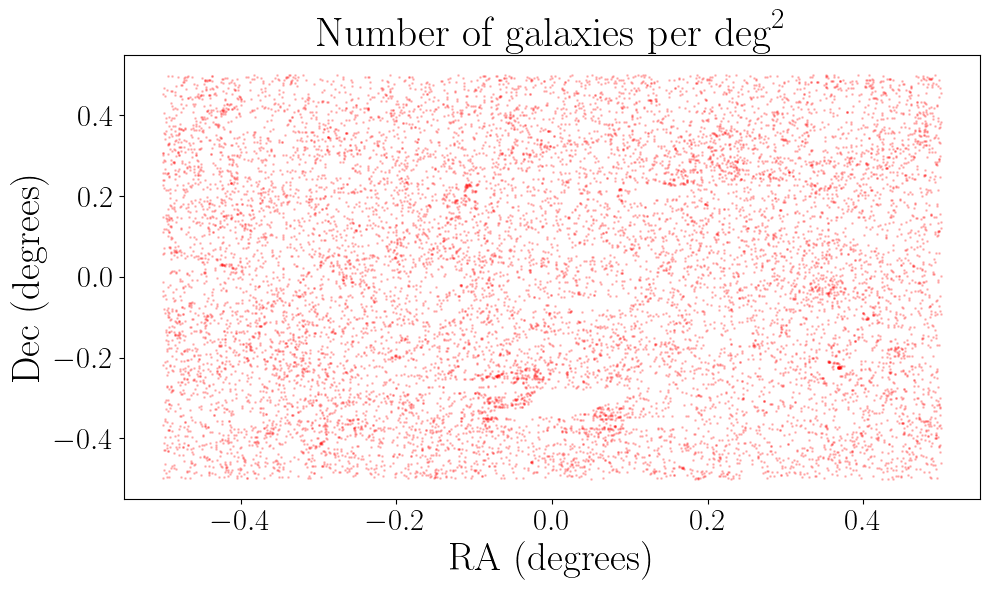

Number of galaxies in plot area: 0


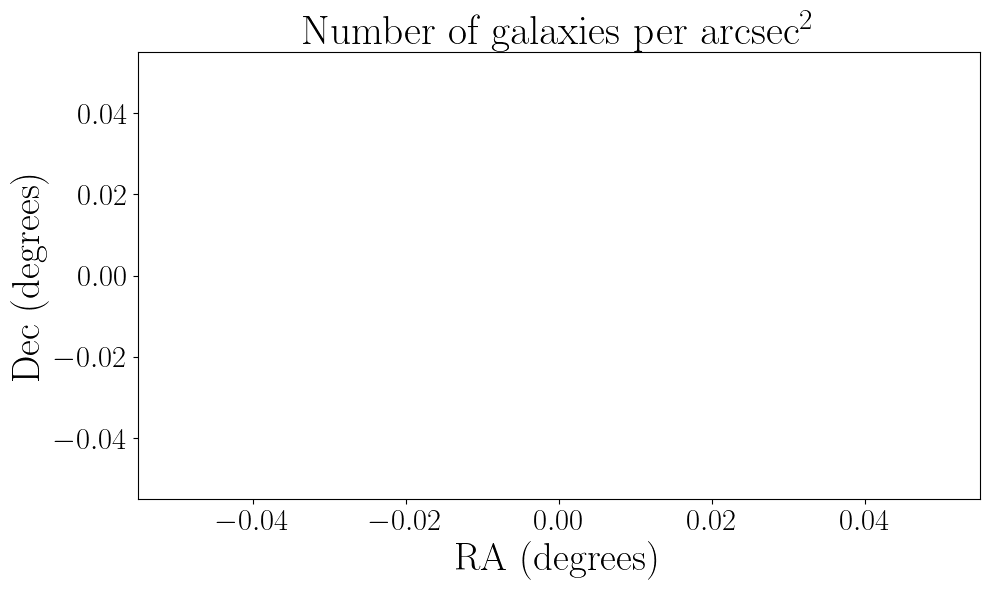

In [38]:
import matplotlib.pyplot as plt

ra = df["ra"].values
ra = (ra + 180) % 360 - 180
dec = df["dec"].values
apparent_mag_i = df["apparent_mag_i"].values
z = df["redshift"].values

apparent_mag_i_threshold_lower = 19.5
apparent_mag_i_threshold_higher = 22
apparent_mag_i_mask = (apparent_mag_i >= apparent_mag_i_threshold_lower) & (apparent_mag_i <= apparent_mag_i_threshold_higher)

plot_length = 1 # deg^2
ra_center = 0
dec_center = 0

ra_width = plot_length / np.cos(np.radians(dec_center))

ra_mask = (ra >= ra_center - ra_width/2) & (ra <= ra_center + ra_width/2)
dec_mask = (dec >= dec_center - plot_length/2) & (dec <= dec_center + plot_length/2)
mask = ra_mask & dec_mask & apparent_mag_i_mask
print(f"Number of galaxies in plot area: {mask.sum()}")

plt.style.use("~/research/my_plot_style.style")
plt.figure()
plt.scatter(ra[mask], dec[mask], s=1, color='red', alpha=0.2)
plt.title("Number of galaxies per $\mathrm{deg}^2$")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.grid()
plt.show()



plot_length = 1 / 3600 # deg^2
ra_center = -0.35
dec_center = -0.22

ra_width = plot_length / np.cos(np.radians(dec_center))


ra_mask = (ra >= ra_center - ra_width/2) & (ra <= ra_center + ra_width/2)
dec_mask = (dec >= dec_center - plot_length/2) & (dec <= dec_center + plot_length/2)
mask = ra_mask & dec_mask
print(f"Number of galaxies in plot area: {mask.sum()}")

plt.style.use("~/research/my_plot_style.style")
plt.figure()
plt.scatter(ra[mask], dec[mask], s=100, color='red', alpha=0.5)
plt.title("Number of galaxies per $\mathrm{arcsec}^2$")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.grid()
plt.show()